In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [2]:
from sequence_parser import Sequence, Variable, Variables
from sequence_parser.iq_port import Port
from sequence_parser.instruction import *

In [3]:
import sklearn
from sklearn.decomposition import PCA

In [4]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

## active reste
ef freq

In [5]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [6]:
header = "D:/K_sunada/result/CDY155/"
ef_freq = "/2024-02-18/2024-02-18T182634_cf189ea6-72_active_reset_ef_freq"
dd = datadict_from_hdf5(header + ef_freq +"/data")

S11 = dd['s11']['values']
freq = dd['ef_freq']['values']
S11_PCA = PCA_transform(S11.real, S11.imag)[0]

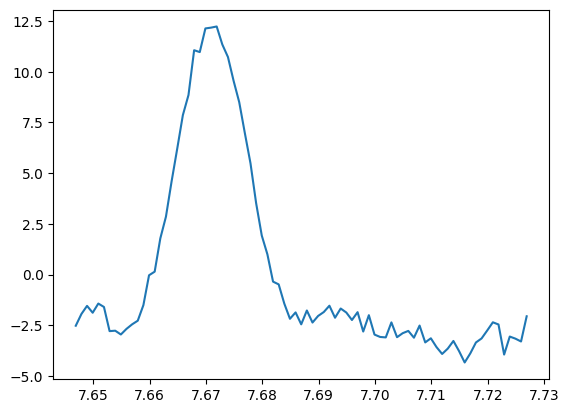

In [7]:
plt.plot(freq, S11_PCA)

In [8]:
par_ini = {
    'amp': 8,
    'const':0,
    'center':7.682,
    'k':0.008
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [9]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
result = model.fit(data = -S11_PCA, params = params, freq = freq)
result

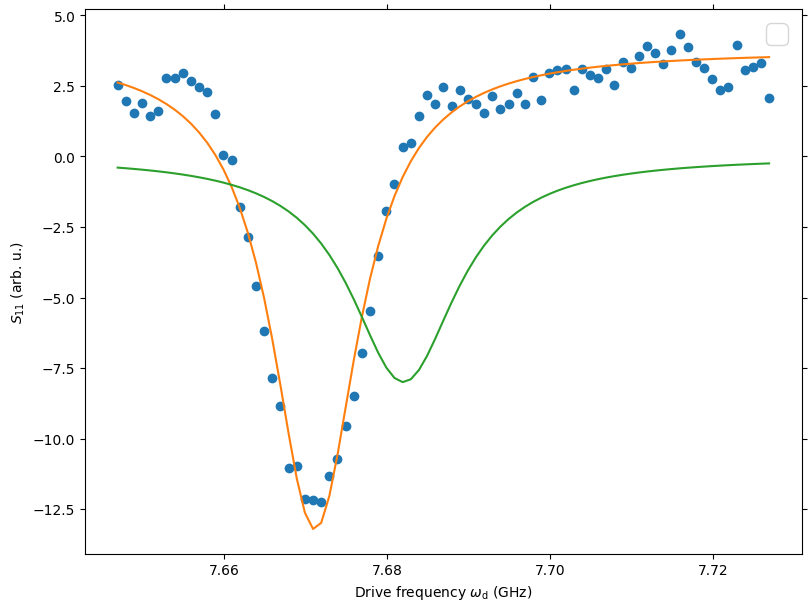

In [10]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(freq, result.init_fit)
# plt.xlim(7.95, 8.065)

plt.title("")
plt.legend("")
plt.xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()

ef amplitude

In [11]:
ef_amp =  "/2024-02-18/2024-02-18T183821_747d1bb1-73_active_reset_ef_amp"
dd = datadict_from_hdf5(header + ef_amp +"/data")

S11 = dd['s11']['values'][0:60]
freq = dd['ef_amplitude']['values'][0:60]
S11_PCA = PCA_transform(S11.real, S11.imag)[0]

In [12]:
def cos(x, amp, freq, phi, const):
    return amp * np.cos(2*np.pi*x*freq+phi) + const

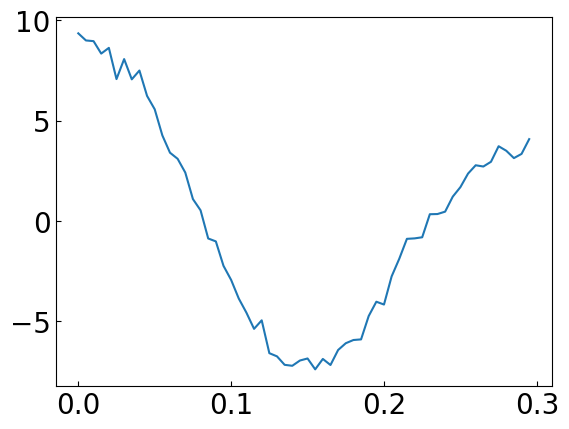

In [13]:
plt.plot(freq, S11_PCA)

In [14]:
par_ini= {'amp': 7,'freq':3.2,'phi':np.pi,'const':0}
par_min= {'amp': 0,'freq':0,'phi':-2*np.pi,'const':-np.inf}
par_max= {'amp': np.inf,'freq':np.inf,'phi':2*np.pi,'const':np.inf}
par_vary= {'amp': True,'freq': True,'phi': True,'const': True}

In [15]:
model = lmfit.Model(cos)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
result = model.fit(data = -S11_PCA, params = params, x = freq)
result

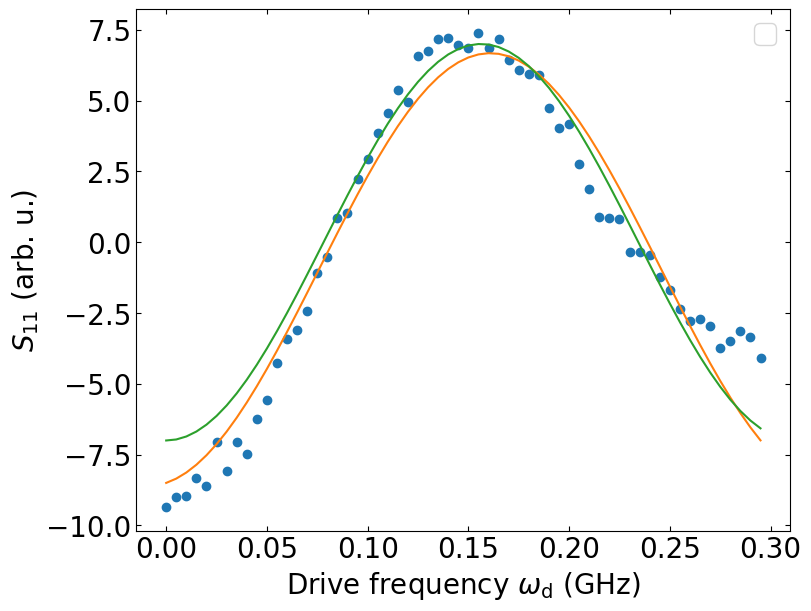

In [16]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(freq, result.init_fit)
# plt.xlim(7.95, 8.065)

plt.title("")
plt.legend("")
plt.xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()

In [17]:
1/2/2.94086454

0.170018031500356

## FFT

In [18]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [19]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

## 2/16 photon shape & photon number

In [53]:
header = "D:/K_sunada/result/CDY155/"

In [54]:
def square(freq, amp, duration):
    x = np.linspace(0, duration-1, duration)
    y = amp* np.cos(2*np.pi* freq*(x*1e-9))
    env = np.zeros(duration) + amp
    return x, y, env

In [55]:
from scipy.constants import *

In [56]:
def watt_dbm(watt):
    return 10*np.log10(watt*1e3)

def dbm_watt(dBm):
    return (10**(dBm/10))*1e-3

In [57]:
dbm_watt(-18.05)

1.5667510701081486e-05

In [58]:
def photon_number(pulse, freq, atten_fixed, atten_fridge, atten_RT, sample_rate, P_vna):
    #pulse: [x, y, env], atten: dBm, samplerate: s, P_vna: W (AWG amp=1.0)
    x = pulse[0]
    y = pulse[2] #env

    atten_W = 10**((atten_fixed + atten_fridge + atten_RT)/10)
    ene = 0
    for t in range(int(len(x)/sample_rate*1e-9)):
        ene = ene + (y[2*t]**2)*sample_rate
    print(watt_dbm(P_vna*atten_W))

    return ene * P_vna * atten_W/ (2*np.pi*hbar*freq)


In [59]:
ene = 0
x = [0, 1, 2, 3, 4, 5, 6]
y = [1, 1, 1, 1, 1, 1, 1]
for t in range(int(len(x)/2)):
    ene = ene + (y[2*t]**2)*2

ene

6

Generated photon shape

array([-95000000.,  95000000.])

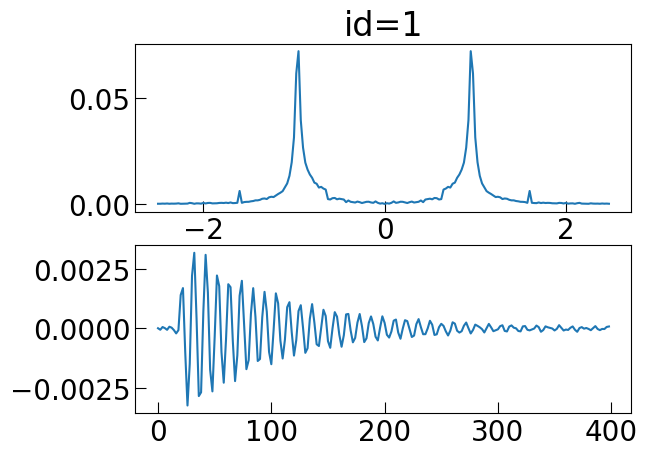

In [60]:
id = 4
duration = 200
data = "/2024-02-18/2024-02-18T171640_0ad3b17a-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][id][0:duration]
y = dd['waveform']['values'][id][0:duration]
x_fft = FFT(x, y)[0]
y_fft = FFT(x, y)[1]

# x_fft1 = FFT(np.linspace(0, 260, 260), time_reverse(data, 7,1.2173913e+08, 130)[0])[0]
# y_fft1 = FFT(np.linspace(0, 260, 260), time_reverse(data, 7,1.2173913e+08, 130)[0])[1]
peak1 = x_fft[signal.argrelmax(y_fft, order=30)]
fig, (ax1, ax2) = plt.subplots(nrows=2)
ax1.set_title("id=1")
ax1.plot(x_fft, y_fft)
ax2.plot(x, y)
peak1

In [61]:
ph_if = [62.5e6, 72.5e6, 82.5e6, 90e6, 95e6]

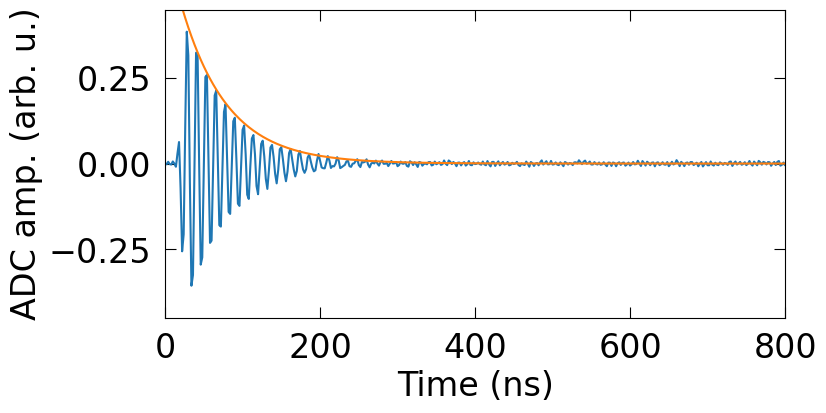

In [86]:
id = 2
duration = 520
ph_if = [62.5e6, 72.5e6, 82.5e6, 90e6, 95e6]
data = "/2024-02-18/2024-02-18T171640_0ad3b17a-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][id][0:duration]
y = dd['waveform']['values'][id][0:duration]
y_shift =  y[13:duration-7]* np.exp(-1j*2 *np.pi* ph_if[id]*(x[13:duration-7]*1e-9))
y_LPF = np.array(np.abs(LPF(y_shift, 500e6, 25e6, 40e6, 5, 40))*2)

amp = [0.00571881, 0.01057035, 0.00660134, 0.00632839,0.00444275]
gamma = [0.01426486, 0.02273654, 0.01688674, 0.01522837, 0.01104741]
fig, ax = plt.subplots(figsize=(8, 4),nrows=1)
plt.rcParams["font.size"] = 24
# plt.title("Rabi(amp)")
plt.tick_params(pad = 10,top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.major.size"] = 8
plt.rcParams["ytick.major.size"] = 8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

ax.plot(x, y*1e2)
ax.plot(x, amp[id]*np.exp(-gamma[id]*x)*1e2)
plt.title("")
ax.set_ylim(-0.45, 0.45)
ax.set_xlim(0, 800)
ax.set_xlabel('Time (ns)')
ax.set_ylabel('ADC amp. (arb. u.)')
# plt.savefig('photon003_0.png', bbox_inches='tight')
plt.show()

In [30]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

par_ini_t1 = {'gamma': 1/250,'amp':0.4,'const':0}
par_min_t1 = {'gamma': 0,'amp':0,'const':-np.inf}
par_max_t1 = {'gamma': np.inf,'amp':np.inf,'const':np.inf,}
par_vary_t1 = {'gamma': True,'amp':True,'const':False}
model = lmfit.Model(Dephase)

In [31]:
params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
# result1 = model.fit(data = LPF_env_1[::-1][50:], params = params, delay = x_1[50:])
result = model.fit(data = y_LPF[20:250], params = params, delay = x[13:duration-7][20:250])

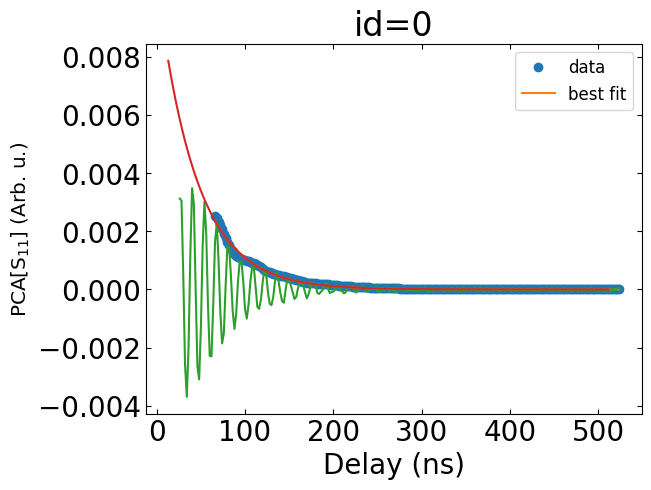

In [32]:
fig, (ax) = plt.subplots(dpi=100)
plt.title("id=0")
plt.rcParams["font.size"] = 12
plt.tick_params(top='on',bottom='on',left='on',right='on',)
result.plot_fit(ax = ax)
plt.plot(x[13:duration-7][0:250], dd['waveform']['values'][id][13:duration-7][0:250])

# plt.plot(x_2,result2.init_fit, label='init fit')
x_interp = np.linspace(13, 499+13, 250)
y_interp = result.model.func(x_interp, **result.best_values)
plt.plot(x_interp, y_interp)
# ax.set_ylim(-8, 15)
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel('Delay (ns)')#, size='large')
ax.set_ylabel('PCA[S$_{11}$] (Arb. u.)', size='large')

plt.show()
result

In [33]:
amp = [0.00571881, 0.01057035, 0.00660134, 0.00632839,0.00444275]
gamma = [0.01426486, 0.02273654, 0.01688674, 0.01522837, 0.01104741]

## Photon shape

10285000000.0
-120.5493100353141


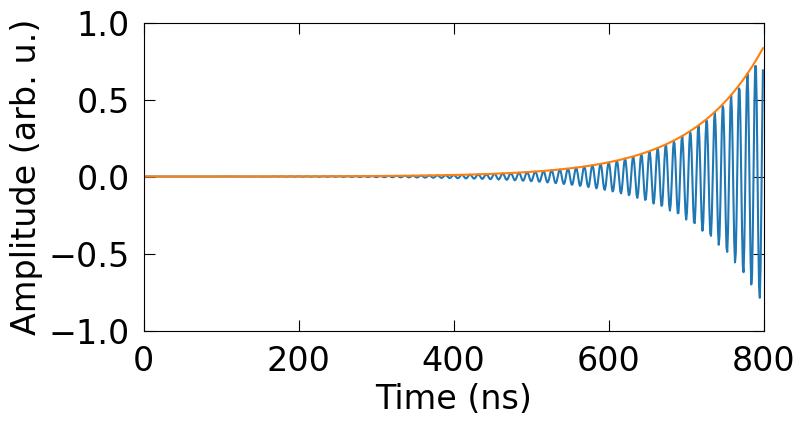

In [84]:
fig, (ax0) = plt.subplots(figsize=(8, 4),nrows=1)
plt.rcParams["font.size"] = 24
plt.rcParams["xtick.major.size"] = 8
plt.rcParams["ytick.major.size"] = 8
plt.tick_params(pad = 10, top='on',bottom='on`',left='on',right='on', color ="black" )
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.xticks(np.arange(0, 801, 200))
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'Amplitude (arb. u.)')
ax0.set_xlim(0, 800)
ax0.set_ylim(-1, 1)

id = 4
duration = 520
header = "D:/K_sunada/result/CDY155/"
data = "/2024-02-18/2024-02-18T171640_0ad3b17a-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][id][0:duration]
y = dd['waveform']['values'][id][0:duration]
ph_if = [62.5e6, 72.5e6, 82.5e6, 90e6, 95e6]
y_shift =  y[13:duration-7]* np.exp(-1j*2 *np.pi* ph_if[id]*(x[13:duration-7]*1e-9))
y_LPF = np.array(np.abs(LPF(y_shift, 500e6, 15e6, 40e6, 5, 40))*2)

x = x[0+13:250+13]
y = y[0+13:250+13]*1e2
amp = [0.00571881, 0.01057035, 0.00660134, 0.00632839,0.00444275]
gamma = [0.01426486, 0.02273654, 0.01688674, 0.01522837, 0.01104741]
x = np.linspace(0, 799, 800)
y_env = (amp[id]*np.exp(-(gamma[id])*(x+26))*1e2)[::-1]
time_reversed_waveform = (y_env*np.cos(2*np.pi* ph_if[id]*(x*1e-9)))
# fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.plot(x, time_reversed_waveform*0.25*1e1)
plt.plot(x, y_env*0.25*1e1)


y_env = time_reversed_waveform*0.4
pulse = [x, y, y_env]
readout_lo_freq = 10.38e9
rf_freq = readout_lo_freq-ph_if[id]
print(rf_freq)
atten_fixed =  -52.5
atten_fridge = -20
atten_RT = -30
sample_rate = 2e-9
P_vna = 1.567e-5
photon_number(pulse, rf_freq, atten_fixed, atten_fridge, atten_RT, sample_rate,P_vna)
# plt.savefig('waveform_tr1.png', bbox_inches='tight')
plt.show()

In [35]:
tr_amp_0tm = [0.053, 0.098, 0.138, 0.169, 0.195]
tr_amp_1tm = [0.041, 0.074, 0.105, 0.128, 0.147]
tr_amp_2tm = [0.052, 0.095, 0.134, 0.164, 0.189]
tr_amp_3tm = [0.051, 0.093, 0.13, 0.159, 0.184]
tr_amp_4tm = [0.058, 0.107, 0.15, 0.184, 0.213]

In [36]:
tr_amp_0 = [0.169, 0.309, 0.437, 0.534, 0.618]
tr_amp_1 = [0.128, 0.234, 0.33, 0.404, 0.467]
tr_amp_2 = [0.164, 0.3, 0.424, 0.52, 0.6]
tr_amp_3 = [0.16, 0.292, 0.412, 0.505, 0.583]
tr_amp_4 = [0.184, 0.336, 0.476, 0.582, 0.672]

10301110000.0
-108.40931003531409


7.7729501420732605

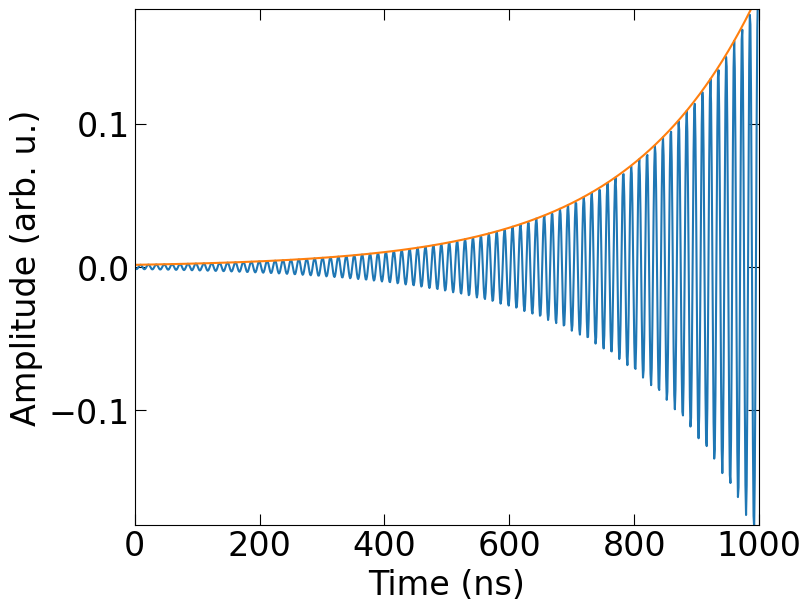

In [37]:
photon_amplitude =[0.338, 0.617, 0.872, 1.068, 1.233] #square
photon_amplitude = [0.282, 0.515, 0.728, 0.891, 1.029] #tr

ph_if = [74.04e6, 77.88e6, 78.85e6, 78.85e6, 78.89e6, 80.00e6, 75.71e6, 80.00e6, 85.00e6]
data_id = 4
# time_reversed_waveform = np.array(square(ph_if[4], 0.05, 500) )

# time_reversed_waveform = square(ph_if[data_id], 0.05, 500)
## photon shape ### 
id = 4
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.title("")
ax.set_xlabel('Time (ns)', size='large')
ax.set_ylabel('Amplitude (arb. u.)', size='large')

amp = [5.0130e-04, 8.1523e-04, 0.00122458, 0.00150458, 0.00215715, 0.00246627, 0.00290790, 0.00604601]
gamma = [0.00147027, 0.00264687, 0.00458680, 0.00656348, 0.00972759	, 0.01271420, 0.01645340, 0.02609383]
ph_duration = 999
x = np.linspace(0, ph_duration-1, ph_duration)
y_env = amp[id]*np.exp(-(gamma[id]/2)*(x+26))*1e2
time_reversed_waveform = (y_env*np.cos(2*np.pi* ph_if[4]*(x*1e-9)))[::-1]
y_env = y_env[::-1]
plt.plot(x, time_reversed_waveform)
plt.plot(x, y_env)
plt.xlim(0, 1000)
plt.ylim(-0.18, 0.18)
ax.set_yticks([-0.1, 0, 0.1])
# plt.savefig('waveform1000_defence.png', bbox_inches='tight')

##ph num

pulse = [x, y, y_env]
readout_lo_freq = 10.38e9
rf_freq = readout_lo_freq-ph_if[id]
print(rf_freq)
atten_fixed =  -50.36
atten_fridge = -20
atten_RT = -30 +10
sample_rate = 2e-9
P_vna = 1.567e-5
photon_number(pulse, rf_freq, atten_fixed, atten_fridge, atten_RT, sample_rate,P_vna)


In [38]:
1/0.00972759*10

1028.003852958441

In [39]:
ph_duramp = [0.197, 0.196, 0.1955, 0.195, 0.1945]

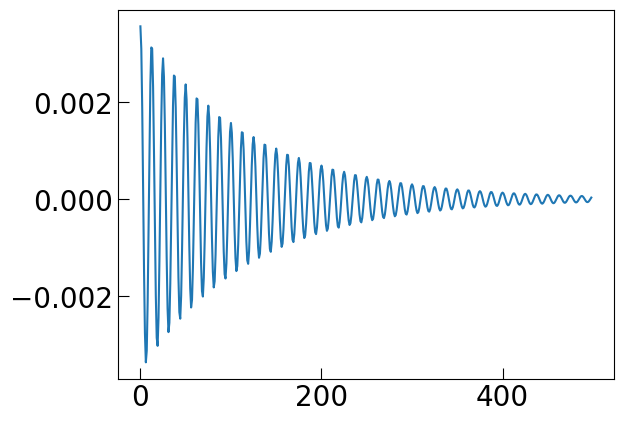

In [40]:

fogi_delay = 29
fogi_amp = 0.6
fogi_duration = 500
fogi_freq = 5.3905

ph_phase = [0, np.pi/2, np.pi, -np.pi/2]

ph_if = [76e6, 79e6, 80e6, 76e6, 85e6, 92.5e6, 87.5e6, 80e6, 95e6, 80e6]
data_id = 2
ph_amp =0.338#(10dB)[0.222, 0.405,0.573, 0.702, 0.811] #[0.7, 1.28, 1.81, 2.22, 2.56]
# ph_amp = 3.03 #(10dB)[3.03, 5.53, 7.83, 9.6, 11.07]#[9.6, 17.5, 24.8, 30.3, 35]


exp_env_x = np.linspace(0, 999, 1000)
exp_env_y =0.6335*np.exp(-0.00819161*exp_env_x)
exp_y = (exp_env_y* np.cos(2*np.pi* ph_if[2]*(exp_env_x*1e-9)))
time_reversed_waveform = np.array( exp_y[500:999])#[::-1] 
control_pulse = time_reversed_waveform  * ph_amp 
    
plt.plot(np.linspace(0, 498, 499), control_pulse)

In [41]:
ph_amp_tr = [0.098, 0.180, 0.254, 0.311, 0.359]

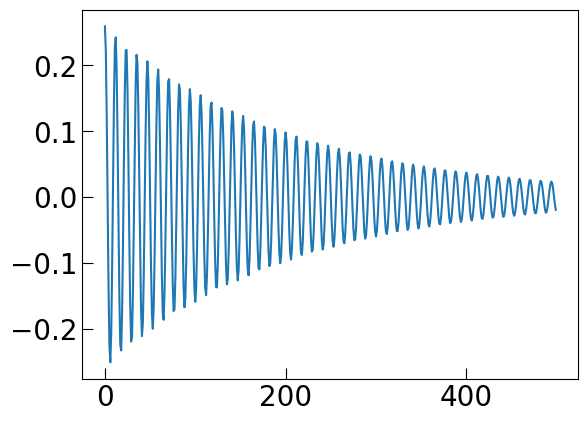

In [42]:
id = 4
duration = 520
header = "D:/K_sunada/result/CDY154/"
data = "/2024-01-17/2024-01-17T143735_84bc5e10-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][id][0:duration]
y = dd['waveform']['values'][id][0:duration]
y_shift =  y[13:duration-7]* np.exp(-1j*2 *np.pi* ph_if[id]*(x[13:duration-7]*1e-9))
y_LPF = np.array(np.abs(LPF(y_shift, 500e6, 15e6, 40e6, 5, 40))*2)

x = x[0+13:250+13]
y = y[0+13:250+13]*1e2
amp = [5.0130e-04, 8.1523e-04, 0.00122458, 0.00150458, 0.00215715, 0.00246627, 0.00290790, 0.00604601]
gamma = [0.00147027, 0.00264687, 0.00458680, 0.00656348, 0.00972759	, 0.01271420, 0.01645340, 0.02609383]
x = np.linspace(0, 499, 500)
y_env = amp[id]*np.exp(-(gamma[id]/2)*(x+26))*1e2
time_reversed_waveform = (y_env*np.cos(2*np.pi* ph_if[4]*(x*1e-9)))#[::-1]

plt.plot(x, time_reversed_waveform*1.362)

In [43]:
sq_ph_du = [0.377, 0.338, 0.308, 0.285, 0.266, 0.251, 0.239]

In [44]:
ph_amp_sq_10 = [0.107, 0.195, 0.276, 0.338, 0.390]

In [45]:
ph_amp_sq = [0.338, 0.617, 0.872, 1.068, 1.233]
ph_amp_sq1 = [1.379, 1.511, 1.631]

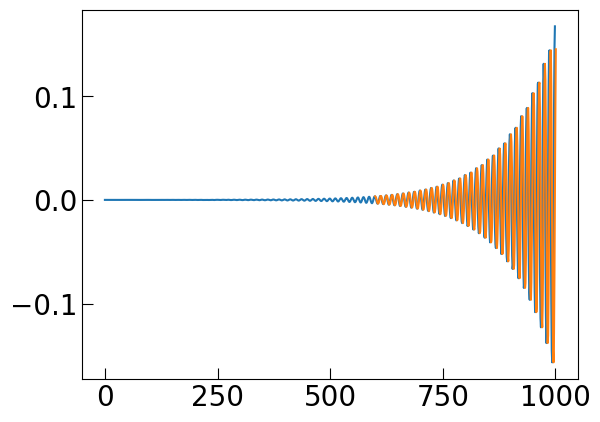

In [46]:
exp_env_x = np.linspace(0, 999, 1000)
exp_env_y = 0.00215715*np.exp(-0.00972759*(exp_env_x+26))*1e2
exp_y = (exp_env_y* np.cos(2*np.pi* 80e6*(exp_env_x*1e-9)))[::-1]
length = 400
plt.plot(exp_env_x, exp_y)
control_pulse = np.array(exp_y[999-length:999])# *0.311
plt.plot(np.linspace(0, len(control_pulse)+1, len(control_pulse))+600, control_pulse)



In [47]:
photon_amplitude = [0.311, 0.568, 0.803, 0.983, 1.135]

In [48]:
def time_reverse(data, id,f_if, duration, awg):
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values'][id][0:duration]
    y = dd['waveform']['values'][id][0:duration]
    y = y[::-1]
    y1 =  y* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
    y_LPF = np.array(np.abs(LPF(y1, 500e6, 10e6, 30e6, 5, 40))*2**0.5)*awg
    
    x_comp = []
    y_comp = []
    for i in range(len(y_LPF)-1):
        x_comp.append(x[i])
        x_comp.append((x[i]+x[i+1])/2)
        y_comp.append(y_LPF[i])
        y_comp.append((y_LPF[i]+y_LPF[i+1])/2)
    x_comp.append(x[-1])
    x_comp.append(x[-1]+1)
    y_comp.append(y_LPF[-1])
    y_comp.append(y_LPF[-1])
    time = np.array(x_comp)
    control_pulse = np.array(y_comp) * np.cos(2*np.pi* f_if*(time*1e-9))
    return x_comp, control_pulse, np.array(y_comp)

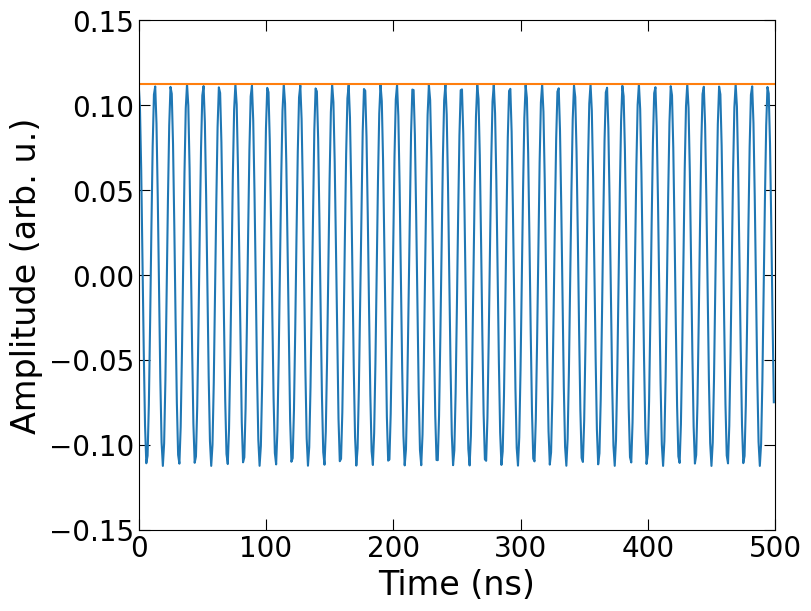

In [49]:
## square 0.03-1.21
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.title("")
ax.set_xlabel('Time (ns)', size='large')
ax.set_ylabel('Amplitude (arb. u.)', size='large')

ph_if = [74.04e6, 77.88e6, 78.85e6, 78.85e6, 78.89e6, 80.00e6, 75.71e6, 80.00e6, 85.00e6]
ph_amp =0.15#[0.222, 0.405,0.573, 0.702, 0.811] #[0.7, 1.28, 1.81, 2.22, 2.56](1 + 0.5 * ph_amp_id)
pulse = np.array(square(ph_if[4], 0.05, 500) )* ph_amp
plt.ylim(-0.15, 0.15)

plt.plot(pulse[0]/ph_amp, pulse[1]*15)
plt.plot(pulse[0]/ph_amp, pulse[2]*15)
plt.xlim(0, 500)
# plt.savefig('sq_waveform.png', bbox_inches='tight')
plt.show()

In [50]:
3/0.00819161

366.2283726886412